--- Stage 1: Loading Feature-Rich Data ---
Successfully loaded JSON file from: C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\processed data\json_2508\patches_coco_with_features.json
Successfully processed 10860 unique cell annotations.

--- Stage 2: Exploratory Data Analysis (3 Classes) ---
Summary statistics for each feature, grouped by class:

Feature: original_area
             count         mean          std    min     25%     50%     75%  \
class_name                                                                    
cbc          941.0  2117.582359   736.833860  386.0  1669.0  2112.0  2518.0   
other       6961.0  2112.977015  1012.490504   55.0  1324.0  2136.0  2764.0   
rbc         2958.0  2366.411765   715.482651  362.0  1947.0  2363.0  2786.0   

               max  
class_name          
cbc         4915.0  
other       6875.0  
rbc         6774.0  

Feature: aspect_ratio
             count      mean       std       min       25%       50%  \
class_name       

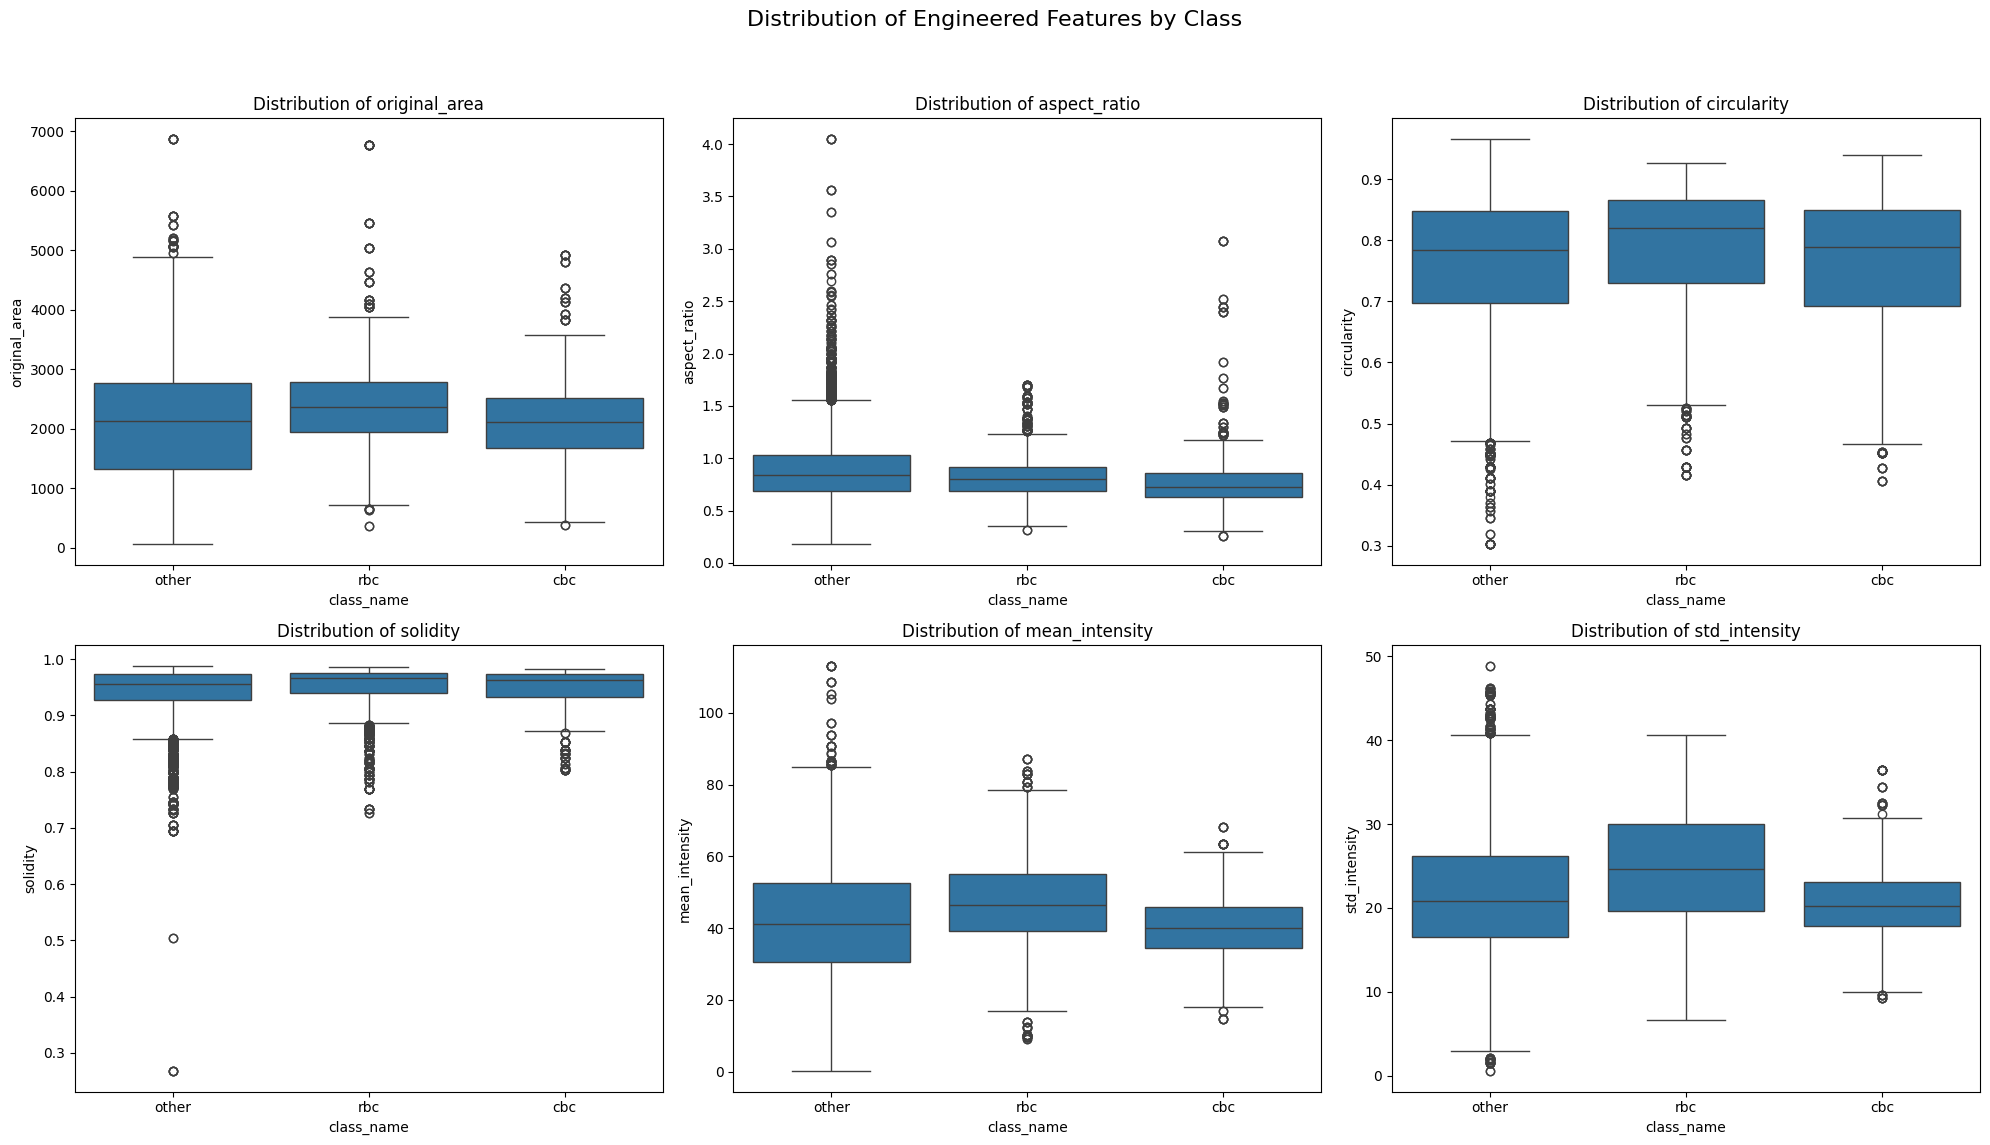

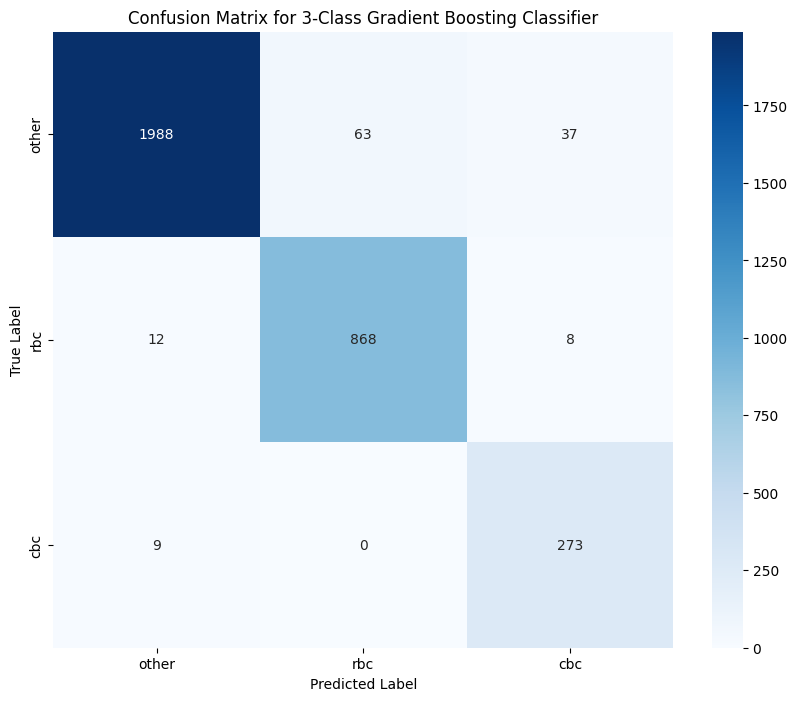

In [1]:
# ─── 1) Imports & Setup ───────────────────────────────────────────
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight

# ─── 2) File Path (Please double-check this is correct) ───────────
JSON_PATH = r'C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\processed data\json_2508\patches_coco_with_features.json'


# ─── 3) Load and Process Data ──────────────────────────────────────
print("--- Stage 1: Loading Feature-Rich Data ---")
try:
    with open(JSON_PATH, 'r') as f:
        coco_data = json.load(f)
    print(f"Successfully loaded JSON file from: {JSON_PATH}")
except FileNotFoundError:
    print(f"--- ERROR: FILE NOT FOUND ---")
    print(f"The script could not find the file at the path specified: {JSON_PATH}")
    print("Please ensure this path is correct and run again.")
    coco_data = None

if coco_data and coco_data.get('annotations'):
    # --- De-duplicate annotations to process each cell once ---
    unique_annotations = {}
    for ann in coco_data['annotations']:
        original_bbox_tuple = tuple(ann['original_bbox'])
        image_id = ann.get('image_id', 0)
        unique_id = (image_id, original_bbox_tuple)
        
        if unique_id not in unique_annotations:
            unique_annotations[unique_id] = ann

    df = pd.DataFrame(list(unique_annotations.values()))
    print(f"Successfully processed {len(df)} unique cell annotations.")

    # --- Prepare data for 3-class analysis ---
    features = ['original_area', 'aspect_ratio', 'circularity', 'solidity', 'mean_intensity', 'std_intensity']
    
    # Use the original 3-class mapping
    CLASS_MAP = {0: 'other', 1: 'rbc', 2: 'cbc'}
    df['class_name'] = df['category_id'].map(CLASS_MAP)


    # ─── 4) Summary Statistics and Visualizations ───────────────────
    print("\n--- Stage 2: Exploratory Data Analysis (3 Classes) ---")
    print("Summary statistics for each feature, grouped by class:")
    for feature in features:
        print(f"\nFeature: {feature}")
        print(df.groupby('class_name')[feature].describe())

    # Create and save boxplots
    print("\nGenerating feature distribution boxplots...")
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Distribution of Engineered Features by Class', fontsize=16)
    axes = axes.flatten()
    for i, feature in enumerate(features):
        # Ensure the order is consistent for plots
        order = ['other', 'rbc', 'cbc']
        sns.boxplot(ax=axes[i], x='class_name', y=feature, data=df, order=order)
        axes[i].set_title(f'Distribution of {feature}')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('feature_distribution_boxplots_3class.png')
    print("Saved feature boxplots to 'feature_distribution_boxplots_3class.png'")


    # ─── 5) Train Gradient Boosting Model (3 Classes) ───────────────
    print("\n--- Stage 3: Training Gradient Boosting 3-Class Classifier ---")
    X = df[features]
    y = df['category_id'] # Use the original category_id for the 3-class target

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    
    # Handle class imbalance for all three classes
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
    print("Calculated sample weights to handle 3-class imbalance.")

    # Initialize the Gradient Boosting model for multi-class classification
    model = GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=7,
        subsample=0.8,
        random_state=42
    )

    print("Training model...")
    model.fit(X_train, y_train, sample_weight=sample_weights)


    # ─── 6) Evaluate the Model ──────────────────────────────────────
    print("\n--- Stage 4: Evaluating the 3-Class Gradient Boosting Model ---")
    y_pred = model.predict(X_test)

    print("\nClassification Report:")
    report = classification_report(y_test, y_pred, target_names=CLASS_MAP.values())
    print(report)

    print("Generating confusion matrix plot...")
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_MAP.values(), yticklabels=CLASS_MAP.values())
    plt.title('Confusion Matrix for 3-Class Gradient Boosting Classifier')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig('gradientboosting_confusion_matrix_3class.png')
    print("Saved confusion matrix to 'gradientboosting_confusion_matrix_3class.png'")
    print("\n--- Analysis Complete ---")

else:
    print("\nCould not proceed with analysis as no annotations were found in the JSON file.")